<a href="https://colab.research.google.com/github/aiman0642/saas-retention-intelligence/blob/main/02_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 2 — Exploratory Data Analysis

**Project:** SaaS Customer Retention Intelligence System

**Goal of this notebook:** move past "what are the columns" (Module 1) into
"what is actually happening in this business" — churn rate, and how it
varies by plan, industry, tenure, engagement, and revenue. Every chart here
should answer a specific question, not just decorate the notebook.


## 2.1 Mount Google Drive & Load Processed Data



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

PROJECT_DIR = "/content/drive/MyDrive/saas-retention-intelligence"
RAW_DIR = f"{PROJECT_DIR}/data/raw"
PROCESSED_DIR = f"{PROJECT_DIR}/data/processed"

accounts = pd.read_csv(f"{PROCESSED_DIR}/accounts.csv", parse_dates=["signup_date"])
subscriptions = pd.read_csv(f"{PROCESSED_DIR}/subscriptions.csv", parse_dates=["start_date", "end_date"])
feature_usage = pd.read_csv(f"{PROCESSED_DIR}/feature_usage.csv", parse_dates=["usage_date"])
support_tickets = pd.read_csv(f"{PROCESSED_DIR}/support_tickets.csv", parse_dates=["submitted_at", "closed_at"])
churn_events = pd.read_csv(f"{PROCESSED_DIR}/churn_events.csv", parse_dates=["churn_date"])

print(f"accounts:        {accounts.shape}")
print(f"subscriptions:   {subscriptions.shape}")
print(f"feature_usage:   {feature_usage.shape}")
print(f"support_tickets: {support_tickets.shape}")
print(f"churn_events:    {churn_events.shape}")

accounts:        (500, 10)
subscriptions:   (5000, 14)
feature_usage:   (25000, 8)
support_tickets: (2000, 9)
churn_events:    (600, 9)


## 2.2 Build an Account-Level Analysis Table

Everything below asks questions at the *account* level ("which accounts
churn"), but the raw data is spread across 5 tables. Build one row-per-
account table by aggregating each child table up to `account_id`. This
table is EDA-only for now — Module 5 (Feature Engineering) will build the
real modeling feature set more carefully.

In [4]:
# Latest subscription per account (most accounts have one, some have several
# over time from upgrades/downgrades/renewals)
latest_sub = (
    subscriptions.sort_values("start_date")
    .groupby("account_id", as_index=False)
    .last()[["account_id", "plan_tier", "mrr_amount", "arr_amount", "billing_frequency",
             "auto_renew_flag", "upgrade_flag", "downgrade_flag"]]
)

# Feature usage aggregated per account (via subscription_id -> account_id)
usage_by_sub = feature_usage.groupby("subscription_id").agg(
    total_usage_count=("usage_count", "sum"),
    total_usage_duration_secs=("usage_duration_secs", "sum"),
    total_errors=("error_count", "sum"),
    distinct_features_used=("feature_name", "nunique"),
).reset_index()

sub_to_account = subscriptions[["subscription_id", "account_id"]]
usage_by_account = usage_by_sub.merge(sub_to_account, on="subscription_id", how="left") \
    .groupby("account_id", as_index=False).sum(numeric_only=True)
usage_by_account = usage_by_account.drop(columns=["subscription_id"], errors="ignore")

# Support ticket aggregates per account
support_by_account = support_tickets.groupby("account_id").agg(
    ticket_count=("ticket_id", "count"),
    avg_satisfaction=("satisfaction_score", "mean"),
    avg_resolution_hours=("resolution_time_hours", "mean"),
    escalation_count=("escalation_flag", "sum"),
).reset_index()

# Assemble
account_view = accounts.merge(latest_sub, on="account_id", how="left", suffixes=("", "_sub"))
account_view = account_view.merge(usage_by_account, on="account_id", how="left")
account_view = account_view.merge(support_by_account, on="account_id", how="left")

# Accounts with no usage/support rows genuinely have zero activity, not missing data
fill_zero_cols = ["total_usage_count", "total_usage_duration_secs", "total_errors",
                   "distinct_features_used", "ticket_count", "escalation_count"]
account_view[fill_zero_cols] = account_view[fill_zero_cols].fillna(0)

# Tenure: days between signup and either churn (if churned) or "today" (dataset max date, as a proxy for "now")
reference_date = feature_usage["usage_date"].max()
account_view = account_view.merge(
    churn_events[["account_id", "churn_date"]].drop_duplicates("account_id"),
    on="account_id", how="left"
)
account_view["tenure_days"] = (
    account_view["churn_date"].fillna(reference_date) - account_view["signup_date"]
).dt.days

print(f"account_view shape: {account_view.shape}")
account_view.head(3)

account_view shape: (500, 27)


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag,plan_tier_sub,mrr_amount,arr_amount,billing_frequency,auto_renew_flag,upgrade_flag,downgrade_flag,total_usage_count,total_usage_duration_secs,total_errors,distinct_features_used,ticket_count,avg_satisfaction,avg_resolution_hours,escalation_count,churn_date,tenure_days
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,Basic,836,10032,monthly,True,False,False,535,152339,38,50,2.0,3.000000,23.000000,0.0,2024-11-23,38
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True,Pro,882,10584,monthly,True,False,False,355,101136,14,32,3.0,4.000000,38.000000,0.0,NaT,502
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False,Pro,98,1176,annual,True,False,False,821,251210,48,78,3.0,4.666667,43.666667,0.0,2024-10-06,40


## 2.3 Overall Churn Rate

Overall churn rate: 22.0%


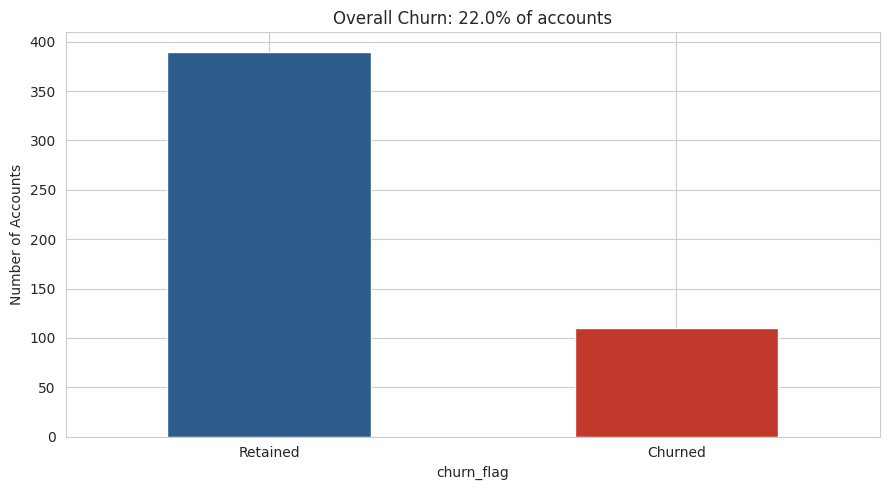

In [5]:
overall_churn_rate = account_view["churn_flag"].mean()
print(f"Overall churn rate: {overall_churn_rate:.1%}")

ax = account_view["churn_flag"].value_counts().sort_index().plot(
    kind="bar", color=["#2E5C8A", "#C0392B"]
)
ax.set_xticklabels(["Retained", "Churned"], rotation=0)
ax.set_ylabel("Number of Accounts")
ax.set_title(f"Overall Churn: {overall_churn_rate:.1%} of accounts")
plt.tight_layout()
plt.show()

## 2.4 Churn by Plan Tier

Do month-to-month / lower plans churn more than higher-commitment plans?

plan_tier
Enterprise    0.220779
Basic         0.220238
Pro           0.219101
Name: churn_flag, dtype: float64


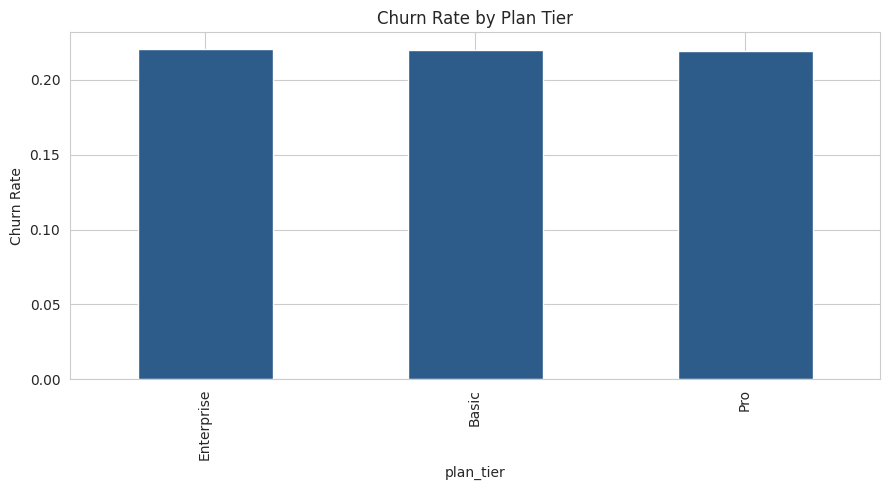

In [6]:
churn_by_plan = account_view.groupby("plan_tier")["churn_flag"].mean().sort_values(ascending=False)
print(churn_by_plan)

ax = churn_by_plan.plot(kind="bar", color="#2E5C8A")
ax.set_ylabel("Churn Rate")
ax.set_title("Churn Rate by Plan Tier")
plt.tight_layout()
plt.show()

## 2.5 Churn by Billing Frequency

Monthly billing is generally lower-commitment than annual — worth checking
if that shows up in churn.

billing_frequency
annual     0.240143
monthly    0.194570
Name: churn_flag, dtype: float64


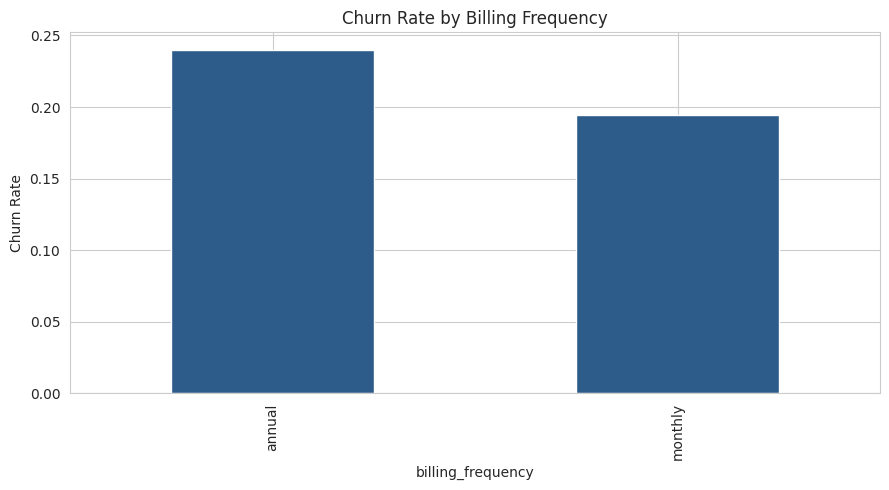

In [7]:
churn_by_billing = account_view.groupby("billing_frequency")["churn_flag"].mean().sort_values(ascending=False)
print(churn_by_billing)

ax = churn_by_billing.plot(kind="bar", color="#2E5C8A")
ax.set_ylabel("Churn Rate")
ax.set_title("Churn Rate by Billing Frequency")
plt.tight_layout()
plt.show()

## 2.6 Churn by Industry & Country

Are certain verticals or regions structurally higher-risk?

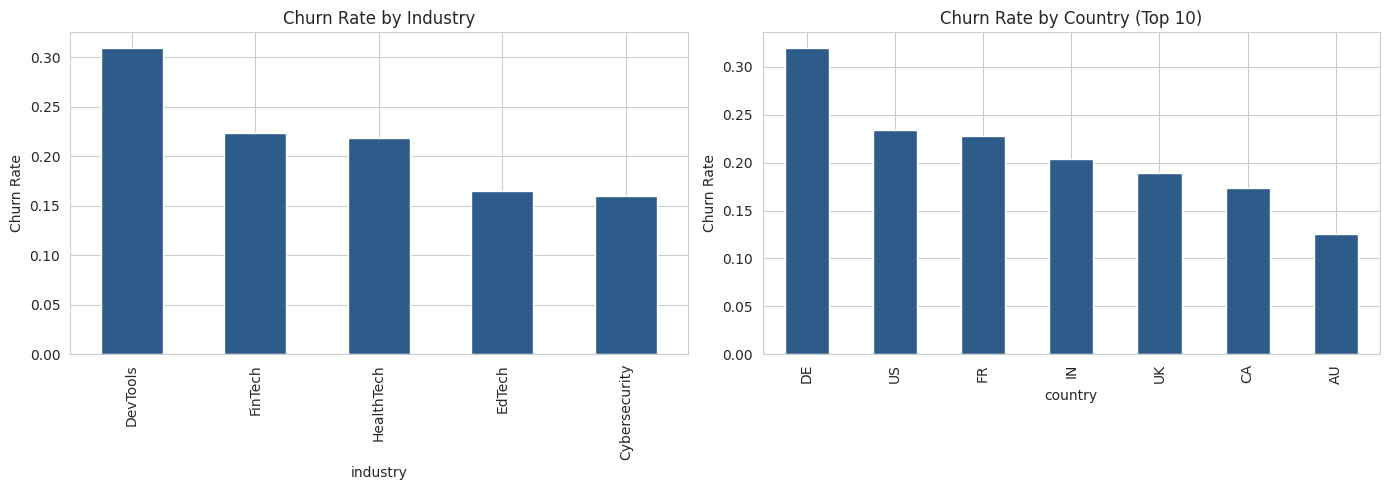

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

account_view.groupby("industry")["churn_flag"].mean().sort_values(ascending=False).plot(
    kind="bar", ax=axes[0], color="#2E5C8A"
)
axes[0].set_title("Churn Rate by Industry")
axes[0].set_ylabel("Churn Rate")

account_view.groupby("country")["churn_flag"].mean().sort_values(ascending=False).head(10).plot(
    kind="bar", ax=axes[1], color="#2E5C8A"
)
axes[1].set_title("Churn Rate by Country (Top 10)")
axes[1].set_ylabel("Churn Rate")

plt.tight_layout()
plt.show()

## 2.7 Churn by Tenure

Does tenure protect against churn (customers who stick around longer churn
less), or is risk flat across tenure?

tenure_bucket
0-3mo     0.188571
3-6mo     0.193182
6-12mo    0.213675
1-2yr     0.299145
Name: churn_flag, dtype: float64


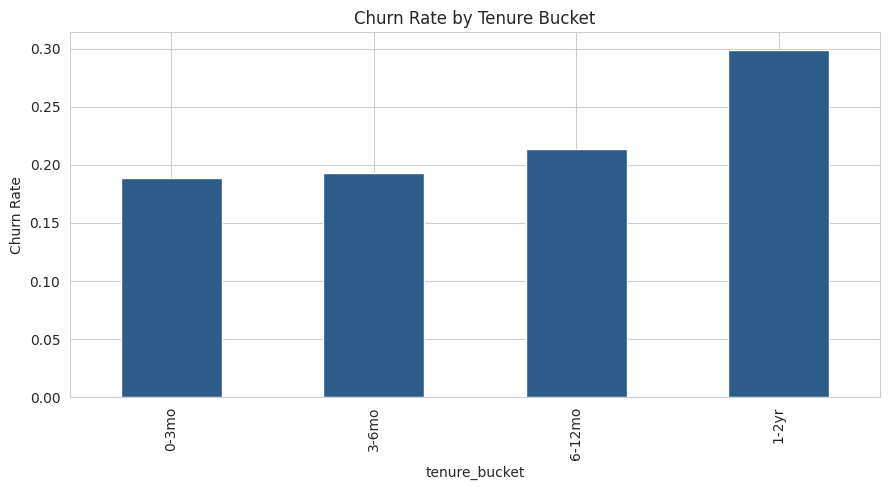

In [9]:
account_view["tenure_bucket"] = pd.cut(
    account_view["tenure_days"],
    bins=[0, 90, 180, 365, 730, np.inf],
    labels=["0-3mo", "3-6mo", "6-12mo", "1-2yr", "2yr+"],
)

churn_by_tenure = account_view.groupby("tenure_bucket", observed=True)["churn_flag"].mean()
print(churn_by_tenure)

ax = churn_by_tenure.plot(kind="bar", color="#2E5C8A")
ax.set_ylabel("Churn Rate")
ax.set_title("Churn Rate by Tenure Bucket")
plt.tight_layout()
plt.show()

## 2.8 Churn by Engagement (Feature Usage)

The core retention hypothesis in most SaaS businesses: low product
engagement predicts churn. Check whether that holds here.

usage_bucket
Low            0.176
Medium-Low     0.200
Medium-High    0.288
High           0.216
Name: churn_flag, dtype: float64


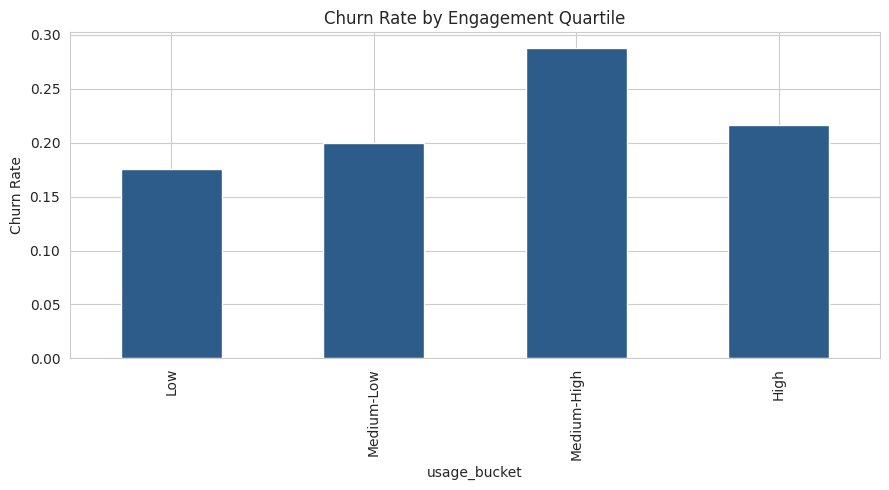

In [10]:
account_view["usage_bucket"] = pd.qcut(
    account_view["total_usage_count"].rank(method="first"),
    q=4, labels=["Low", "Medium-Low", "Medium-High", "High"]
)

churn_by_usage = account_view.groupby("usage_bucket", observed=True)["churn_flag"].mean()
print(churn_by_usage)

ax = churn_by_usage.plot(kind="bar", color="#2E5C8A")
ax.set_ylabel("Churn Rate")
ax.set_title("Churn Rate by Engagement Quartile")
plt.tight_layout()
plt.show()

## 2.9 Churn by Revenue (MRR)

Do higher-paying accounts churn less (more invested) or more (more
price-sensitive / scrutinized)?

mrr_bucket
Low            0.224
Medium-Low     0.192
Medium-High    0.232
High           0.232
Name: churn_flag, dtype: float64


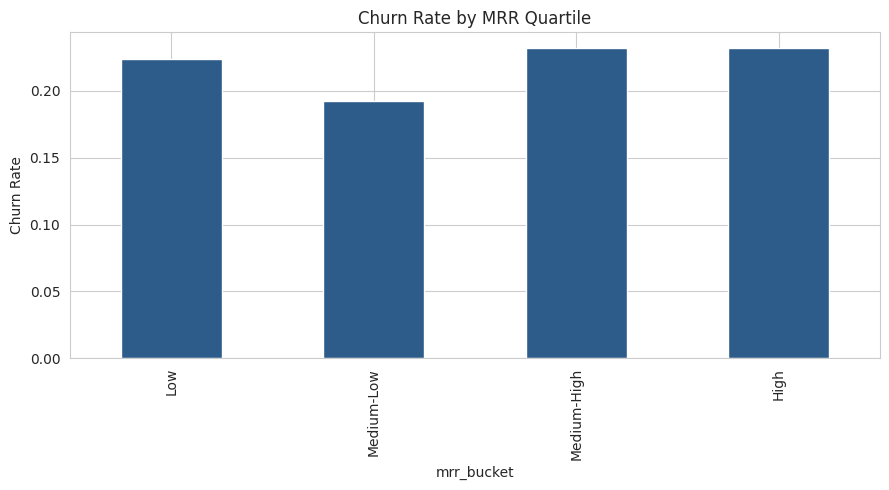

In [11]:
account_view["mrr_bucket"] = pd.qcut(
    account_view["mrr_amount"].rank(method="first"),
    q=4, labels=["Low", "Medium-Low", "Medium-High", "High"]
)

churn_by_mrr = account_view.groupby("mrr_bucket", observed=True)["churn_flag"].mean()
print(churn_by_mrr)

ax = churn_by_mrr.plot(kind="bar", color="#2E5C8A")
ax.set_ylabel("Churn Rate")
ax.set_title("Churn Rate by MRR Quartile")
plt.tight_layout()
plt.show()

## 2.10 Churn by Support Experience

Ticket volume, escalations, and satisfaction scores — does a rocky support
experience precede churn?

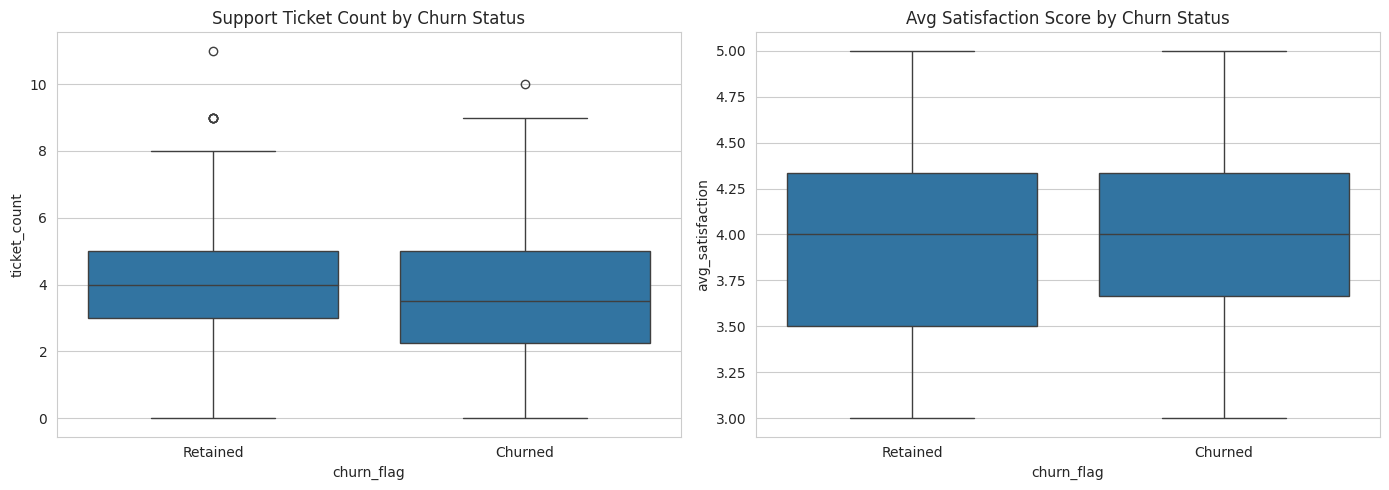

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=account_view, x="churn_flag", y="ticket_count", ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Retained", "Churned"])
axes[0].set_title("Support Ticket Count by Churn Status")

sns.boxplot(data=account_view.dropna(subset=["avg_satisfaction"]), x="churn_flag", y="avg_satisfaction", ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Retained", "Churned"])
axes[1].set_title("Avg Satisfaction Score by Churn Status")

plt.tight_layout()
plt.show()

## 2.11 Correlation Analysis (Numerical Features)

Quick correlation heatmap across numerical features against `churn_flag`
to spot the strongest linear relationships before modeling.

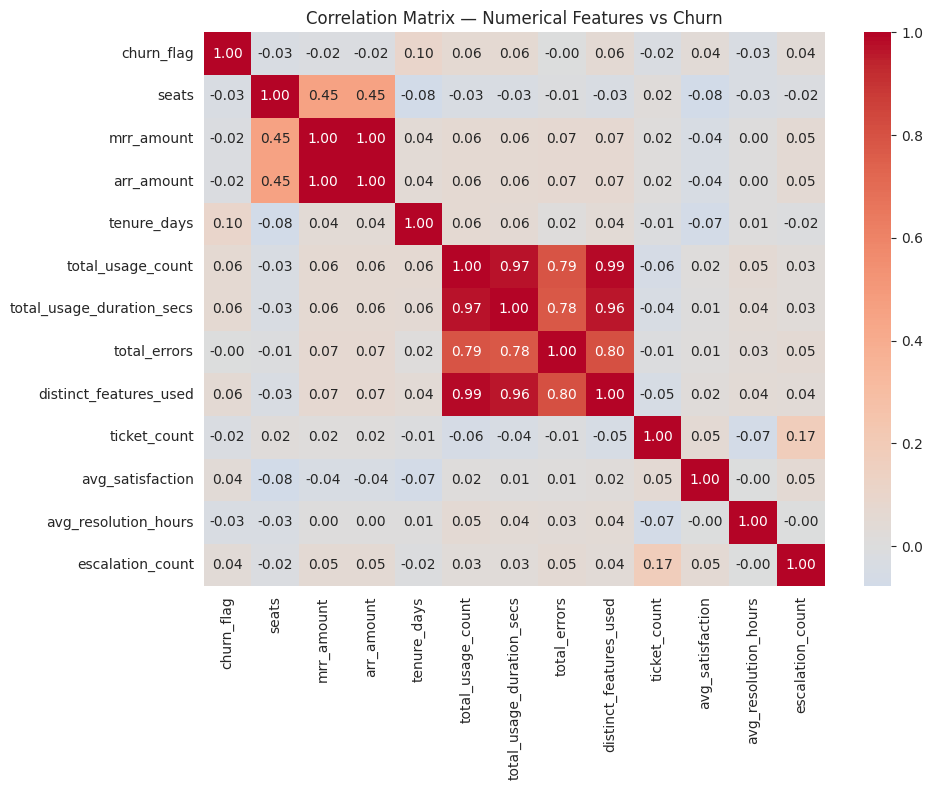


Correlation with churn_flag, sorted:
tenure_days                  0.097157
total_usage_count            0.064186
total_usage_duration_secs    0.063095
distinct_features_used       0.056047
escalation_count             0.035891
avg_satisfaction             0.035700
total_errors                -0.002612
arr_amount                  -0.017499
mrr_amount                  -0.017499
ticket_count                -0.020425
seats                       -0.033437
avg_resolution_hours        -0.033812
Name: churn_flag, dtype: float64


In [13]:
numeric_cols = ["churn_flag", "seats", "mrr_amount", "arr_amount", "tenure_days",
                 "total_usage_count", "total_usage_duration_secs", "total_errors",
                 "distinct_features_used", "ticket_count", "avg_satisfaction",
                 "avg_resolution_hours", "escalation_count"]

corr = account_view[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Numerical Features vs Churn")
plt.tight_layout()
plt.show()

print("\nCorrelation with churn_flag, sorted:")
print(corr["churn_flag"].drop("churn_flag").sort_values(ascending=False))

## 2.12 Churn Reasons (from churn_events)

For accounts that did churn, what reasons were logged?

reason_code
features      114
support       104
budget        104
unknown        95
competitor     92
pricing        91
Name: count, dtype: int64


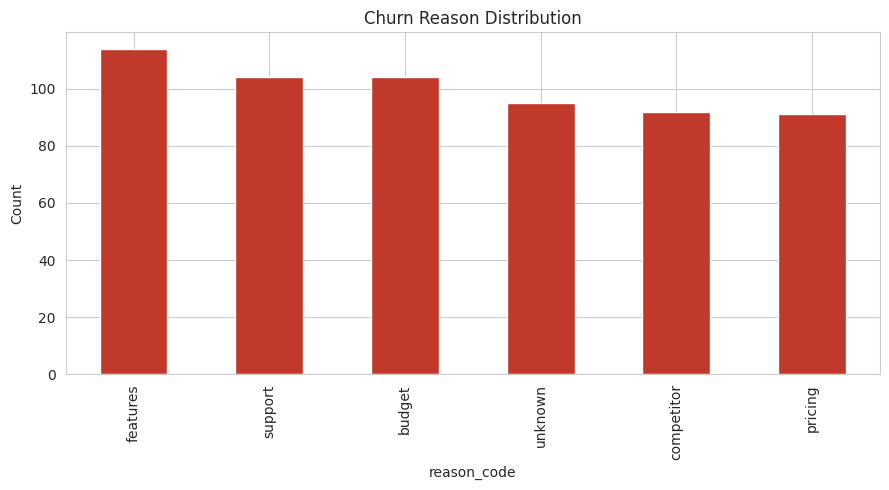

In [14]:
reason_counts = churn_events["reason_code"].value_counts()
print(reason_counts)

ax = reason_counts.plot(kind="bar", color="#C0392B")
ax.set_ylabel("Count")
ax.set_title("Churn Reason Distribution")
plt.tight_layout()
plt.show()

## 2.13 Key Business Insights

Based on the actual outputs above:

- **Overall churn rate:** ~22% of accounts have churned.
- **Plan tier:** churn is essentially flat across Basic, Pro, and
  Enterprise (~22% each) — plan tier alone doesn't separate churners from
  retained accounts in this dataset.
- **Billing frequency:** annual accounts churn slightly *more* than
  monthly (~24% vs ~19%) — counter to the usual assumption that
  longer commitment means lower churn risk. Worth noting rather than
  assuming the opposite.
- **Tenure:** churn risk actually *increases* with tenure (from ~19% in
  the first 3 months up to ~30% at 1–2 years) — the opposite of the
  typical "early-life churn is highest" pattern. This is a notable,
  dataset-specific finding to call out explicitly in the README.
- **Engagement:** no clean monotonic relationship between usage quartile
  and churn — Medium-High usage churns most (~29%), not Low usage as the
  standard hypothesis would predict.
- **Revenue:** churn is roughly flat across MRR quartiles (19–23%) — no
  strong revenue-based risk signal.
- **Strongest correlate:** `tenure_days` (r ≈ 0.10) — positive and weak.
  No feature in this pass shows a strong linear relationship with churn;
  all correlations are under 0.10 in magnitude.
- **Top churn reasons:** fairly evenly spread across `features` (114),
  `support` (104), `budget` (104), `unknown` (95), `competitor` (92), and
  `pricing` (91) — no single dominant driver.



## 2.14 Save EDA-Ready Account View

Persist `account_view` so Module 3 (Cohort Analysis) and Module 5 (Feature
Engineering) can build on it without re-deriving these joins.

In [15]:
account_view.to_csv(f"{PROCESSED_DIR}/account_view_eda.csv", index=False)
print(f"Saved account_view ({account_view.shape}) to {PROCESSED_DIR}/account_view_eda.csv")

Saved account_view ((500, 30)) to /content/drive/MyDrive/saas-retention-intelligence/data/processed/account_view_eda.csv


## 2.15 Module 2 Summary

- Built a single account-level analysis table joining accounts,
  subscriptions, feature usage, and support tickets
- Measured churn rate overall and across plan, billing frequency,
  industry, country, tenure, engagement, revenue, and support experience
- Ran a correlation pass to flag the strongest numerical predictors ahead
  of modeling
- Saved `account_view_eda.csv` for reuse in later modules

**Next:** Module 3 — Cohort & Retention Analysis